Device: cuda
Start Training with Sigma=0.3 ...
Epoch [1/20] Loss: 0.0295
Epoch [5/20] Loss: 0.0047
Epoch [10/20] Loss: 0.0044
Epoch [15/20] Loss: 0.0043
Epoch [20/20] Loss: 0.0043

Starting Evaluation on multiple noise levels...

Sigma      | MSE        | PSNR (dB)  | SSIM      
------------------------------------------------------------
0.1        | 0.0019     | 27.64      | 0.9722    
0.3        | 0.0043     | 23.99      | 0.9413    
0.5        | 0.0186     | 17.49      | 0.6886    

Visualizing results for highest noise (Sigma=0.1)...


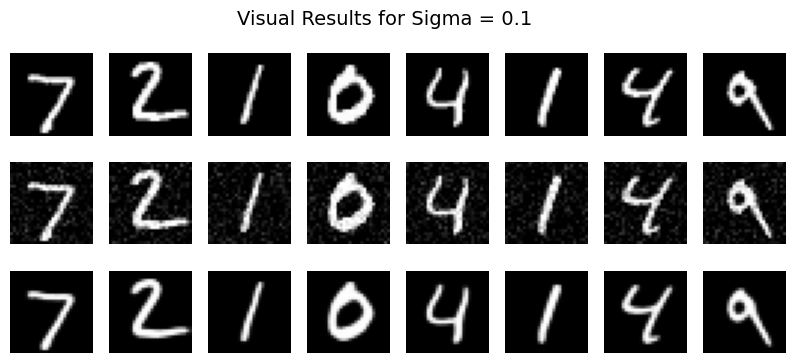

Visualizing results for highest noise (Sigma=0.3)...


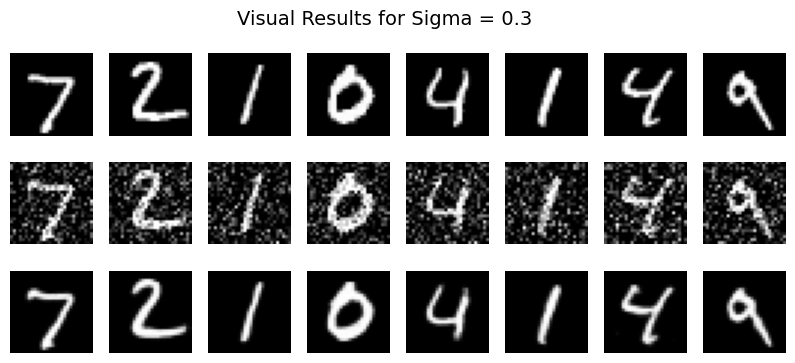

Visualizing results for highest noise (Sigma=0.5)...


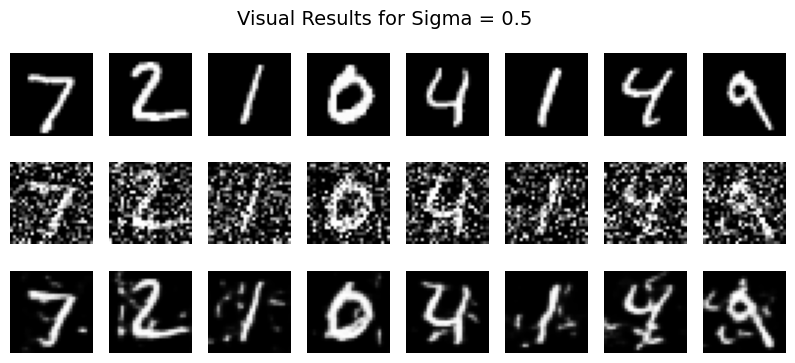

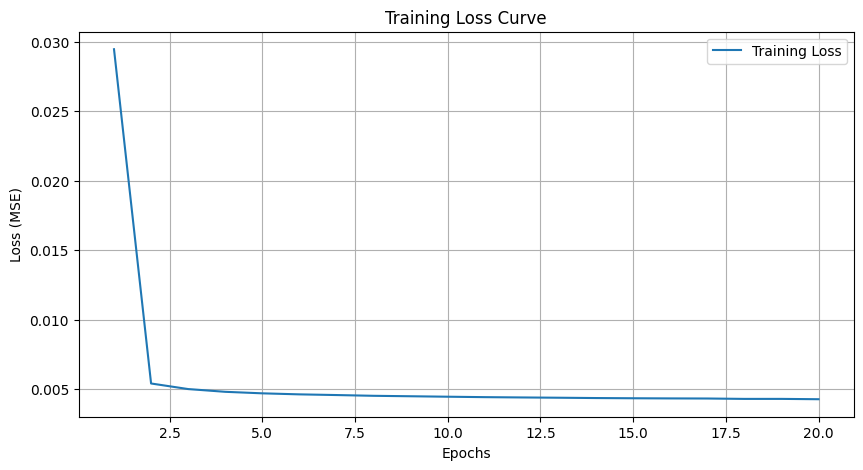

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


# 1. Model Definition

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder: 1x28x28 -> 64x7x7
        self.encoder = nn.Sequential(
            # 1. Conv
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            # 2. BatchNorm
            nn.BatchNorm2d(16),
            # 3. Activation
            nn.ReLU(True),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
        )

        # Decoder: 64x7x7 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),


            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


def get_data(batch_size=128):
    transform = transforms.ToTensor()
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    if sigma <= 0: return x
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, 0.0, 1.0)

def train_one_epoch(model, train_loader, optimizer, criterion, sigma, device):
    model.train()
    running_loss = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        x_noisy = add_gaussian_noise(x, sigma).to(device) # ここで指定のsigmaでノイズ付与

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(train_loader.dataset)


# Evaluation Function (MSE, PSNR, SSIM)
def evaluate_all_levels(model, test_loader, device, noise_levels):
    model.eval()
    print("\n" + "="*60)
    print(f"{'Sigma':<10} | {'MSE':<10} | {'PSNR (dB)':<10} | {'SSIM':<10}")
    print("-" * 60)

    results = {}

    for sigma in noise_levels:
        total_mse = 0.0
        total_psnr = 0.0
        total_ssim = 0.0
        num_batches = 0

        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_noisy = add_gaussian_noise(x, sigma).to(device)
                outputs = model(x_noisy)

                # MSE
                total_mse += nn.MSELoss()(outputs, x).item()

                # PSNR & SSIM
                clean_np = x.cpu().numpy()
                out_np = outputs.cpu().numpy()
                batch_size = x.size(0)

                batch_psnr = 0.0
                batch_ssim = 0.0
                for i in range(batch_size):
                    batch_psnr += psnr(clean_np[i,0], out_np[i,0], data_range=1.0)
                    batch_ssim += ssim(clean_np[i,0], out_np[i,0], data_range=1.0)

                total_psnr += batch_psnr / batch_size
                total_ssim += batch_ssim / batch_size
                num_batches += 1

        avg_mse = total_mse / num_batches
        avg_psnr = total_psnr / num_batches
        avg_ssim = total_ssim / num_batches

        results[sigma] = (avg_mse, avg_psnr, avg_ssim)
        print(f"{sigma:<10} | {avg_mse:<10.4f} | {avg_psnr:<10.2f} | {avg_ssim:<10.4f}")

    print("="*60 + "\n")
    return results

def show_visual_results(model, test_loader, device, sigma):
    model.eval()
    x, _ = next(iter(test_loader))
    x = x.to(device)
    x_noisy = add_gaussian_noise(x, sigma).to(device)
    with torch.no_grad():
        outputs = model(x_noisy)

    # Display top 8 images
    x = x.cpu().numpy()
    x_noisy = x_noisy.cpu().numpy()
    outputs = outputs.cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Visual Results for Sigma = {sigma}", fontsize=14)
    for i in range(8):
        # Clean
        plt.subplot(3, 8, i + 1)
        plt.imshow(x[i, 0], cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel("Clean", fontsize=12)

        # Noisy
        plt.subplot(3, 8, i + 1 + 8)
        plt.imshow(x_noisy[i, 0], cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel(f"Noisy\n(σ={sigma})", fontsize=12)

        # Output
        plt.subplot(3, 8, i + 1 + 16)
        plt.imshow(outputs[i, 0], cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel("Denoised", fontsize=12)
    plt.show()


def main():
    # Settings
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    TRAIN_SIGMA = 0.3          # noise level for training (sigma = 0.1)
    TEST_SIGMAS = [0.1, 0.3, 0.5] # noise levels for testing (sigma = 0.1, 0.3, 0.5)
    EPOCHS = 20
    train_losses = []

    # Setup
    train_loader, test_loader = get_data(batch_size=128)
    model = DenoisingAutoencoder().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # Training
    print(f"Start Training with Sigma={TRAIN_SIGMA} ...")
    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, TRAIN_SIGMA, device)
        train_losses.append(loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{EPOCHS}] Loss: {loss:.4f}")

    # Evaluation Table
    print("\nStarting Evaluation on multiple noise levels...")
    evaluate_all_levels(model, test_loader, device, TEST_SIGMAS)

    # Visual Evaluation
    print("Visualizing results for noise (Sigma=0.1)...")
    show_visual_results(model, test_loader, device, sigma=0.1)
    print("Visualizing results for noise (Sigma=0.3)...")
    show_visual_results(model, test_loader, device, sigma=0.3)
    print("Visualizing results for noise (Sigma=0.5)...")
    show_visual_results(model, test_loader, device, sigma=0.5)

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('Training Loss Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()